<a href="https://colab.research.google.com/github/AbdulMalik300/titanic-survival-analysis/blob/main/titanic_survival_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Survival Analysis
**Business Context:** As a Data Analyst, the goal is to understand which factors
(gender, class, age, family status) influenced passenger survival during the
Titanic disaster, and extract actionable insights from historical data.

## 1. Import Libraries & Load Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs('visualizations', exist_ok=True)

#load dataset
url='https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df=pd.read_csv(url)

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
# Understand structure
print(f"Shape{df.shape}")
df.info()

Shape(891, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  FamilySize   891 non-null    int64  
 13  IsAlone      891 non-null    int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 97.6+ KB


## 2. Data Quality Assessment
Checking missing values, duplicates, and data types before cleaning.

In [10]:
# Missing values audit
missing=df.isnull().sum()
missing_pct=(missing/len(df))*100
print(pd.DataFrame({'Missing Count': missing, 'Missing %':missing_pct.round(2)}))

             Missing Count  Missing %
PassengerId              0       0.00
Survived                 0       0.00
Pclass                   0       0.00
Name                     0       0.00
Sex                      0       0.00
Age                    177      19.87
SibSp                    0       0.00
Parch                    0       0.00
Ticket                   0       0.00
Fare                     0       0.00
Cabin                  687      77.10
Embarked                 2       0.22
FamilySize               0       0.00
IsAlone                  0       0.00


In [11]:
# Duplicate check
print(f"Duplicate Count: {df.duplicated().sum()}")

Duplicate Count: 0


## 3. Data Cleaning

**Strategy:**
- `Age`: 19.87% missing → fill with **median grouped by Pclass** (more accurate than a single global median, since age varies by class)
- `Embarked`: only 2 missing → fill with **mode** (most frequent port)
- `Cabin`: 77% missing → too sparse to use directly; convert into a binary flag `HasCabin` instead of dropping the column entirely
- `Ticket`, `PassengerId`: dropped — no analytical value

In [12]:
# Fill Age using group-wise median (by Pclass)
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# Fill Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Convert Cabin into a binary feature instead of dropping
df['HasCabin'] = df['Cabin'].notnull().astype(int)

# Drop irrelevant/high-missing columns
df.drop(columns=['Cabin', 'Ticket'], inplace=True)

# Verify cleaning
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
FamilySize     0
IsAlone        0
HasCabin       0
dtype: int64


## 4. Feature Engineering
Creating new features that make hidden patterns visible.

In [13]:
# Family size and travel status
df['FamilySize']= df['SibSp']+df['Parch']+1
df['IsAlone']=(df['FamilySize']==1).astype(int)

# Extract title from name (Mr, Mrs, Miss, Master, etc.)
df['Title']=df['Name'].str.extract(r',\s*([^\.]*)\.')

print(df[['FamilySize', 'IsAlone', 'Title']].head())
print(df['Title'].value_counts())


   FamilySize  IsAlone Title
0           2        0    Mr
1           2        0   Mrs
2           1        1  Miss
3           2        0   Mrs
4           1        1    Mr
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


## 5. Descriptive Statistics

In [14]:
print(f"Overall Survival Rate: {df['Survived'].mean():2%}")
print()
print(df[['Age','Fare']].describe())


Overall Survival Rate: 38.383838%

              Age        Fare
count  891.000000  891.000000
mean    29.066409   32.204208
std     13.244532   49.693429
min      0.420000    0.000000
25%     22.000000    7.910400
50%     26.000000   14.454200
75%     37.000000   31.000000
max     80.000000  512.329200


## 6. Exploratory Data Analysis — Survival by Key Factors

In [15]:
print(f"Survived Rate by Gender: {df.groupby('Sex')['Survived'].mean()*100}")



Survived Rate by Gender: Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [16]:
print(f"Srvival Rate by Passanger class: {df.groupby('Pclass')['Survived'].mean()*100}")

Srvival Rate by Passanger class: Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [17]:
# Recreate IsAlone column because df was reloaded
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print(f"Survival Rate by family status (with family VS Alone): {df.groupby('IsAlone')['Survived'].mean()*100}")

Survival Rate by family status (with family VS Alone): IsAlone
0    50.564972
1    30.353818
Name: Survived, dtype: float64


In [18]:
print(f"Survival Rate by Cabin Availability: {df.groupby('HasCabin')['Survived'].mean()*100}")

Survival Rate by Cabin Availability: HasCabin
0    29.985444
1    66.666667
Name: Survived, dtype: float64


## 7. Correlation Analysis
Which numeric factors are most strongly associated with survival?

In [19]:
corr = df[['Survived','Pclass','Age','SibSp','Parch','Fare','FamilySize','HasCabin']].corr()
print(corr['Survived'].sort_values(ascending=False))

Survived      1.000000
HasCabin      0.316912
Fare          0.257307
Parch         0.081629
FamilySize    0.016639
SibSp        -0.035322
Age          -0.047255
Pclass       -0.338481
Name: Survived, dtype: float64


## 8. Probability Analysis

In [20]:
p_survive= df['Survived'].mean()
p_female= df[df['Sex']=='female']['Survived'].mean()
p_male= df[df['Sex']=='male']['Survived'].mean()
p_class1= df[df['Pclass']==1]['Survived'].mean()
p_class2= df[df['Pclass']==2]['Survived'].mean()
p_class3= df[df['Pclass']==3]['Survived'].mean()
p_chlid = df[df['Age']<12]['Survived'].mean()
p_adult = df[df['Age']>=12]['Survived'].mean()

print(f"Overall Survival Rate: {p_survive:2%}")
print(f"Survival Rate by Gender: {p_female:2%}, {p_male:2%}")
print(f"Survival Rate by Class: {p_class1:2%}, {p_class2:2%}, {p_class3:2%}")
print(f"Survival Rate by Age: {p_chlid:2%}, {p_adult:2%}")

Overall Survival Rate: 38.383838%
Survival Rate by Gender: 74.203822%, 18.890815%
Survival Rate by Class: 62.962963%, 47.282609%, 24.236253%
Survival Rate by Age: 57.352941%, 36.816525%


## 9. Visualizations

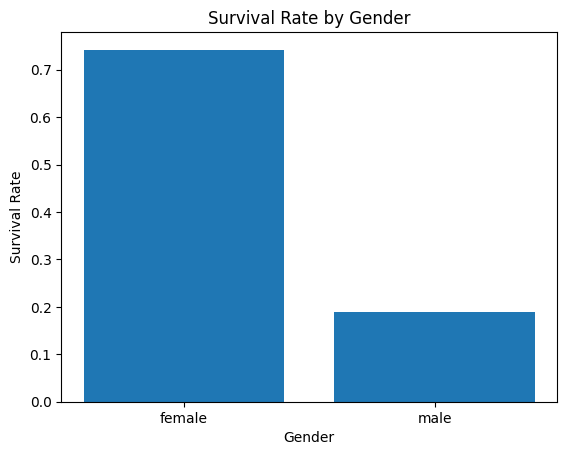

In [23]:
# Graph 1: Survival Rate by Gender
gender_survival= df.groupby('Sex')['Survived'].mean()
plt.bar(gender_survival.index,gender_survival.values)
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Gender')
plt.savefig('visualizations/graph1.png')
plt.show()

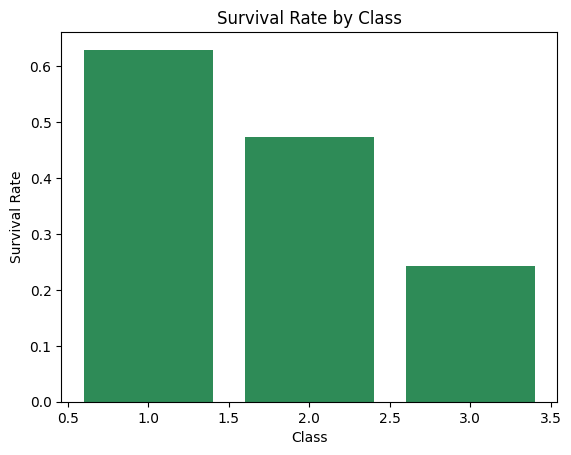

In [24]:
# Graph 2: Survival Rate by Class
class_sruvival= df.groupby('Pclass')['Survived'].mean()
plt.bar(class_sruvival.index,class_sruvival.values, color='seagreen')
plt.xlabel('Class')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Class')
plt.savefig('visualizations/graph2.png')
plt.show()

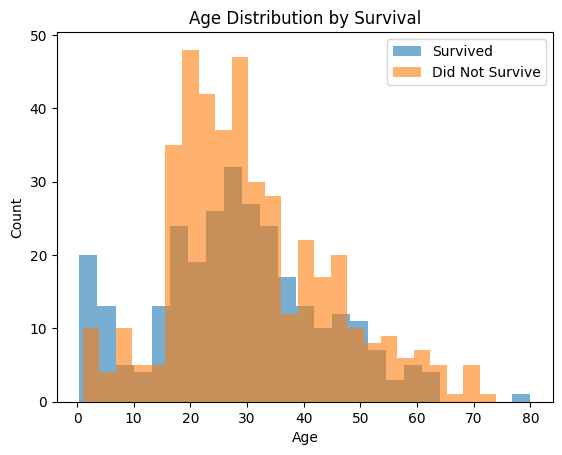

In [3]:
# Graph 3: Age Distribution - Survivors vs Non-Survivors
plt.hist(df[df['Survived']==1]['Age'], bins=25, alpha=0.6, label='Survived')
plt.hist(df[df['Survived']==0]['Age'], bins=25, alpha=0.6, label='Did Not Survive')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution by Survival')
plt.legend()
plt.savefig('visualizations/age_distribution.png')
plt.show()

/tmp/ipykernel_1405/3934156081.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([died_fare, survived_fare], labels=['Did Not Survive', 'Survived'])


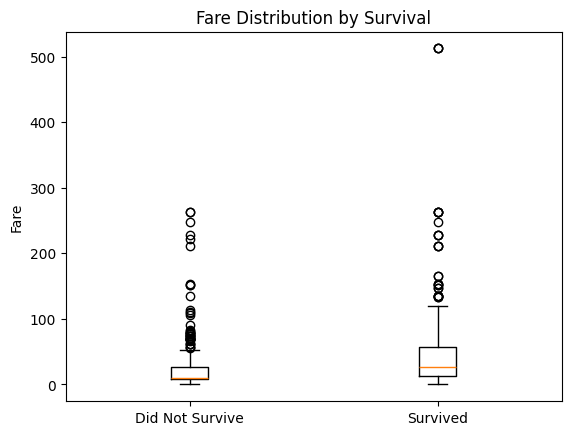

In [4]:
# Graph 4: Fare vs Survival (boxplot manually via matplotlib)
survived_fare = df[df['Survived']==1]['Fare']
died_fare = df[df['Survived']==0]['Fare']
plt.boxplot([died_fare, survived_fare], labels=['Did Not Survive', 'Survived'])
plt.ylabel('Fare')
plt.title('Fare Distribution by Survival')
plt.savefig('visualizations/fare_by_survival.png')
plt.show()

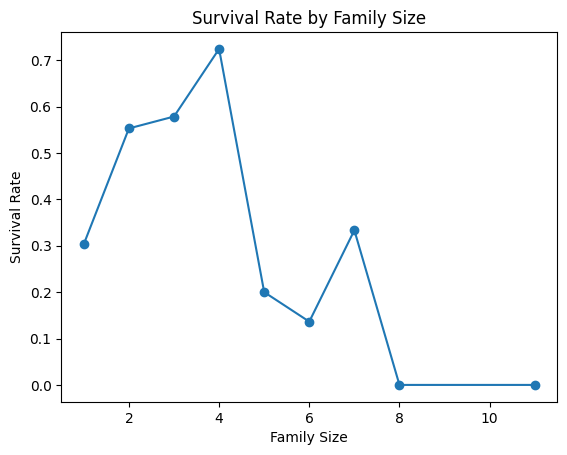

In [25]:
# Graph 5: Family Size vs Survival Rate
family_survival = df.groupby('FamilySize')['Survived'].mean()
plt.plot(family_survival.index, family_survival.values, marker='o')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Family Size')
plt.savefig('visualizations/survival_by_familysize.png')
plt.show()

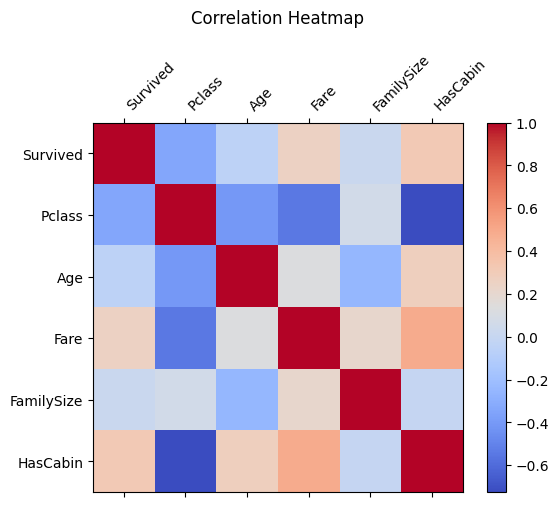

In [26]:
# Graph 6: Correlation Heatmap (manual, matplotlib only)
corr_matrix = df[['Survived','Pclass','Age','Fare','FamilySize','HasCabin']].corr()

fig, ax = plt.subplots()
cax = ax.matshow(corr_matrix, cmap='coolwarm')
fig.colorbar(cax)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='left')
ax.set_yticklabels(corr_matrix.columns)
plt.title('Correlation Heatmap', pad=20)
plt.savefig('visualizations/correlation_heatmap.png')
plt.show()

## 10. Key Findings & Business Insights

1. **Gender was the single biggest survival factor** — women survived at 74.2%
   vs men at 18.9%, confirming the "women and children first" evacuation protocol
   was strongly enforced.

2. **Passenger class strongly predicted survival** — 1st class passengers survived
   at 63.0%, while 3rd class passengers survived at only 24.2%, showing socioeconomic
   status directly impacted access to lifeboats.

3. **Traveling with family improved survival odds** — passengers with family aboard
   survived at 50.6%, compared to 30.4% for those traveling alone, possibly due to
   mutual assistance during evacuation.

4. **Cabin data availability correlated with survival** — passengers with a recorded
   cabin number survived at 66.7% vs 30.0% without, since cabin data was more often
   recorded for higher-fare, upper-deck passengers.

5. **Children under 12 had a notably higher survival rate (57.4%)** than the overall
   average (38.4%), reinforcing that children were prioritized during rescue.

6. **Pclass showed the strongest negative correlation with survival (-0.34)**, making
   it the most influential numeric predictor in the dataset — more significant than
   age or family size.